# In Class Notebook, Map Week


You can always find here: https://github.com/UIUC-iSchool-DataViz/is445_bcubcg_fall2025/blob/master/week08/inClass_week08.ipynb  


In [1]:
import bqplot

In [2]:
# 1. data
shape_data = bqplot.topo_load('map_data/WorldMap.json')

In [3]:
# 2. scales/axis
sc_geo = bqplot.Mercator() # we know this is not the best projection!

In [5]:
# 3. Marks
#bqplot.Map?
shape_map = bqplot.Map(map_data = shape_data, scales={'projection':sc_geo})

In [6]:
# 4. no interactivity

In [9]:
#5. into a figure
fig = bqplot.Figure(marks=[shape_map], fig_margin={'top':0, 'bottom':0, 'left':0, 'right':0})
fig

Figure(fig_margin={'top': 0, 'bottom': 0, 'left': 0, 'right': 0}, marks=[Map(hovered_styles={'hovered_fill': '…

In [10]:
# 1. data -- load US states
shape_data = bqplot.topo_load('map_data/USStatesMap.json')

# 2. scales/axis
sc_geo = bqplot.AlbersUSA() # US-specific projection

# 3. marks
shape_map = bqplot.Map(map_data=shape_data, scales={'projection':sc_geo})

# figure
fig = bqplot.Figure(marks=[shape_map], fig_margin={'top':0, 'bottom':0, 'left':0, 'right':0})
fig

Figure(fig_margin={'top': 0, 'bottom': 0, 'left': 0, 'right': 0}, marks=[Map(hovered_styles={'hovered_fill': '…

In [13]:
!ls /opt/anaconda3/pkgs/bqplot-0.12.30-pyhd8ed1ab_0/site-packages/bqplot/map_data

EuropeMap.json     USCountiesMap.json USStatesMap.json   WorldMap.json


## Geopandas (a little easier to deal with)

In [14]:
import geopandas

In [17]:
import geodatasets

In [18]:
geodatasets.get_path('ny bb')

'/Users/jnaiman/Library/Caches/geodatasets/nybb_16a.zip.unzip/nybb_16a/nybb.shp'

In [19]:
gdf = geopandas.read_file(geodatasets.get_path('ny bb'))

In [20]:
gdf

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


<AxesSubplot:>

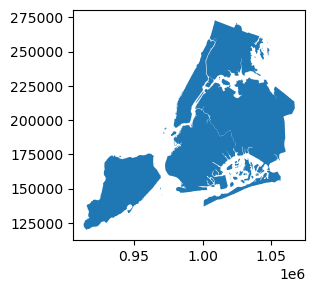

In [23]:
gdf.plot(figsize=(3,3))

In [24]:
gdf.crs # crs = coordinate reference system

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [25]:
gdf.to_crs('epsg:4326').crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<AxesSubplot:>

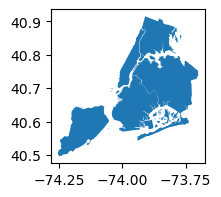

In [27]:
gdf.to_crs('epsg:4326').plot(figsize=(2,2))

In [29]:
#gdf_coastlines = geopandas.read_file('https://www2.census.gov/geo/tiger/TIGER2024/COASTLINE/tl_2024_us_coastline.zip')
# can't use US-based federal data because of shutdown

In [30]:
gdf_councils = geopandas.read_file('https://gisportal.champaignil.gov/ms/rest/services/Open_Data/Open_Data/MapServer/1/query?outFields=*&where=1%3D1&f=geojson')

In [31]:
gdf_councils

,OBJECTID_1,District,Council_me,Shape.STArea(),Shape.STLength(),geometry
0,1219,1,Davion Williams,1.991748e+08,133825.673297,"POLYGON ((-88.27716 40.16364, -88.27732 40.163..."
1,1220,3,Shauna Clayborn,1.382327e+08,73289.747391,"POLYGON ((-88.28312 40.13667, -88.28372 40.136..."
2,1221,2,Bob Pollett,7.472444e+07,50905.604100,"POLYGON ((-88.2468 40.11261, -88.24763 40.1126..."
3,1222,5,Vanna Pianfetti,1.776407e+08,204013.082479,"POLYGON ((-88.31441 40.11698, -88.31441 40.116..."
4,1223,4,Michael Foellmer,6.308923e+07,58697.438268,"POLYGON ((-88.22877 40.11638, -88.22884 40.116..."


<AxesSubplot:>

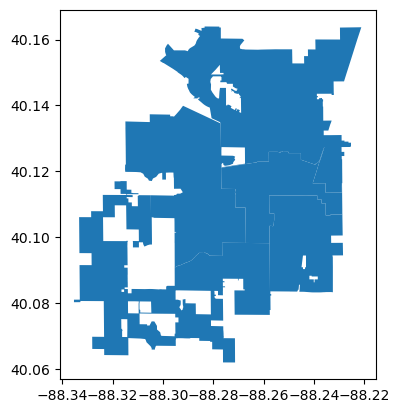

In [32]:
gdf_councils.plot()